In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

Iniciando o pipeline de Machine Learning (previsão de churn)
Dados carregados com sucesso! Total de utilizadores: 10000
Treinando o modelo XGBoost...
Treino concluído
---Relatório de classificação---
              precision    recall  f1-score   support

   Ativo (0)       1.00      1.00      1.00      2189
   Churn (1)       1.00      1.00      1.00       311

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500



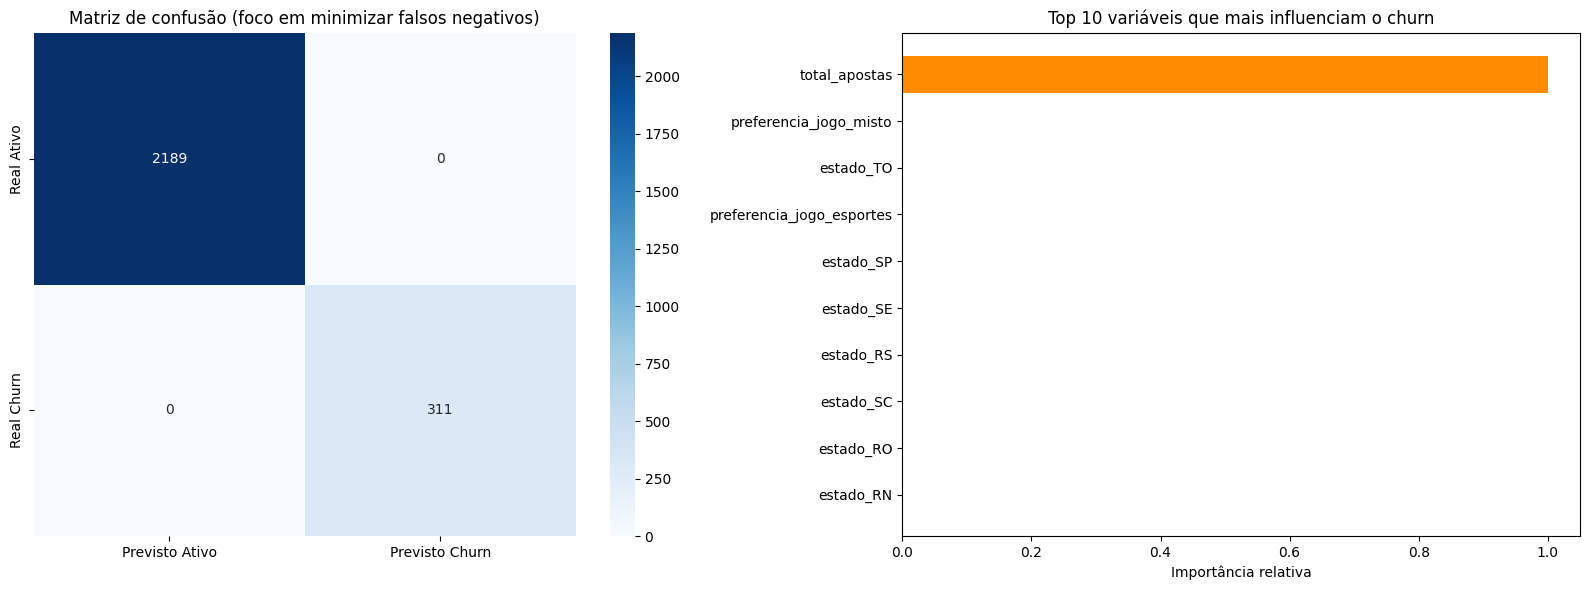

In [5]:
print("Iniciando o pipeline de Machine Learning (previsão de churn)")

try:
    # Localiza a base de dados
    current_path = Path(".").resolve()
    db_path = None
    for folder in [current_path] + list(current_path.parents):
        if (folder / "aposta_ganha_dw.db").exists():
            db_path = folder / "aposta_ganha_dw.db"
            break

    if not db_path:
        raise FileNotFoundError("Base de dados não encontrado")

    # Extração dos dados analíticos
    conn = sqlite3.connect(str(db_path))
    df = pd.read_sql_query("SELECT * FROM tabela_analytics;", conn)
    conn.close()

    print (f"Dados carregados com sucesso! Total de utilizadores: {len(df)}")

    # Pré-processamento (removemos as colunas identificadores que não tem valor preditivo)
    X = df.drop(['user_id', 'nome', 'target_churn'], axis=1)
    y = df['target_churn']

    # Transformação de variáveis categóricas em numéricas (One-Hot Encoding)
    # Transforma 'preferencia_jogo' e 'estado' em colunas binárias (0 ou 1)
    X = pd.get_dummies(X, columns=['estado', 'preferencia_jogo'], drop_first=True)

    # Divisão de dados (treino e teste)
    # Usamos o stratify=y para garantir que a proporção de churn seja igual no treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.25,
                                                        random_state=42,
                                                        stratify=y)
    
    # Balenceamento de Classes 
    # Cálculo (total de casos negativo) / (total de casos positivos)
    peso_churn = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

    print("Treinando o modelo XGBoost...")
    
    # Criação e treino do modelo XGBoost
    modelo_xgb = XGBClassifier(n_estimators=100,
                               max_depth=5,
                               learning_rate=0.1,
                               scale_pos_weight=peso_churn, # Otimizando o recall
                               random_state=42,
                               eval_metric='logloss')
    
    modelo_xgb.fit(X_train, y_train)
    print("Treino concluído")

    # Avaliação e pedrições
    y_pred = modelo_xgb.predict(X_test)

    print("---Relatório de classificação---")
    print(classification_report(y_test, y_pred, target_names=["Ativo (0)", "Churn (1)"]))

    # visualização pda matriz de confusão e importância de variáveis
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Previsto Ativo', 'Previsto Churn'],
                yticklabels=['Real Ativo', 'Real Churn'])
    axes[0].set_title('Matriz de confusão (foco em minimizar falsos negativos)')

    # Importância das variáveis
    importances = modelo_xgb.feature_importances_
    indices = np.argsort(importances)[-10:] # Top 10 variáveis

    axes[1].barh(range(len(indices)), importances[indices], color='darkorange', align='center')
    axes[1].set_yticks(range(len(indices)))
    axes[1].set_yticklabels([X.columns[i] for i in indices])
    axes[1].set_title('Top 10 variáveis que mais influenciam o churn')
    axes[1].set_xlabel('Importância relativa')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Falha na execução: {e}")